In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from StrategicAnalysis import StrategicAnalysis, PREDICTOR_SETS, CGE_OUTCOMES, RAW_NETWORK_INDICATORS, CATEGORY_LABELS

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 10

CATEGORY_COLORS = {
    "Strategic Core Sectors": "#1b9e77",
    "Structurally Critical but Low-Transmission Sectors": "#d95f02",
    "Emerging Leverage Sectors": "#7570b3",
    "Peripheral Limited-Impact Sectors": "#999999",
}

print("Ortam hazir. Rastgelelik tohumu (seed) =", RANDOM_SEED)


Ortam hazir. Rastgelelik tohumu (seed) = 42


In [2]:
sa = StrategicAnalysis(
    snii_path="../01_SNII/3_snii_results.xlsx",
    eipi_path="../02_CGE_EIPI/4_eipi_results.xlsx",
    network_path="../01_SNII/1_network_candidate_indicators.xlsx",
    cge_path="../02_CGE_EIPI/2_cge_counterfactual_results.xlsx",
    io_path="../01_SNII/1-IntermediateInputs.xlsx",
    baseline_path="../02_CGE_EIPI/1_cge_baseline_solution.xlsx",
)
panel = sa.build_panel()

with pd.ExcelWriter("1_merged_index_panel.xlsx", engine="openpyxl") as writer:
    panel.to_excel(writer, sheet_name="merged_panel")
print("Kaydedildi: 1_merged_index_panel.xlsx")


Kaydedildi: 1_merged_index_panel.xlsx


In [3]:
classes = sa.classify()
print("Ana siniflandirma (ortalama esik) dagilimi:")
print(classes["category_main_mean"].value_counts())
print()
print(f"Ortalama vs medyan esik ile kategori degistiren sektor sayisi: {sa.classification_meta['n_changed_mean_vs_median']} / 62")
print(f"Sinirda (borderline) sektor sayisi: {classes['borderline'].sum()} / 62")
display(classes.head(10))


Ana siniflandirma (ortalama esik) dagilimi:
category_main_mean
Structurally Critical but Low-Transmission Sectors    24
Emerging Leverage Sectors                             15
Peripheral Limited-Impact Sectors                     14
Strategic Core Sectors                                 9
Name: count, dtype: int64

Ortalama vs medyan esik ile kategori degistiren sektor sayisi: 8 / 62
Sinirda (borderline) sektor sayisi: 26 / 62


,category_main_mean,category_main_median,category_variant_snii_eipi_ch,category_variant_topsis,category_variant_pca,category_variant_avg,borderline
sector,,,,,,,
sec1,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,False
sec2,Emerging Leverage Sectors,Emerging Leverage Sectors,Peripheral Limited-Impact Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,False
sec3,Emerging Leverage Sectors,Emerging Leverage Sectors,Peripheral Limited-Impact Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,False
sec4,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,False
sec5,Strategic Core Sectors,Strategic Core Sectors,Strategic Core Sectors,Strategic Core Sectors,Strategic Core Sectors,Strategic Core Sectors,False
sec6,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Emerging Leverage Sectors,Peripheral Limited-Impact Sectors,Emerging Leverage Sectors,False
sec7,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Peripheral Limited-Impact Sectors,Structurally Critical but Low-Transmission Sec...,Peripheral Limited-Impact Sectors,True
sec8,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,Peripheral Limited-Impact Sectors,Structurally Critical but Low-Transmission Sec...,Structurally Critical but Low-Transmission Sec...,False
sec9,Strategic Core Sectors,Strategic Core Sectors,Structurally Critical but Low-Transmission Sec...,Emerging Leverage Sectors,Strategic Core Sectors,Strategic Core Sectors,True


In [4]:
with pd.ExcelWriter("2_strategic_classification_table.xlsx", engine="openpyxl") as writer:
    classes.to_excel(writer, sheet_name="classification_table")
    pd.Series(sa.classification_meta, name="value").drop("variant_axes").to_frame().to_excel(writer, sheet_name="thresholds_meta")
print("Kaydedildi: 2_strategic_classification_table.xlsx")


Kaydedildi: 2_strategic_classification_table.xlsx


### Ana Sınıflandırma Dörtlü Grafiği

**Yorum:** Dörtlü grafikteki her nokta bir sektörü temsil eder; kesikli çizgiler her eksenin
ortalama eşiğini gösterir. Sağ-üst çeyrekteki (Strategic Core) sektörler hem ağda merkezi hem de
genel dengede güçlü yayılım yaratan sektörlerdir — politika önceliklendirmesinde en yüksek getiriyi
sunan grup budur.


### Varyant Sınıflandırmaları (Section 3.2)

## 4. H1 — Pozitif İlişki Hipotezi (Section 4, H1)

**Ne:** (a) `SNII_DIM` ile birincil EIPI hedefi arasındaki Spearman/Pearson korelasyonu; (b) yedi ham
ağ göstergesinin her biri ile EIPI hedefi arasındaki korelasyon; (c) her ağ göstergesi ile her CGE
çıktısı arasındaki 7x7 korelasyon matrisi.

**Neden:** H1, ağ merkeziliğinin genel-denge önemiyle **pozitif ama tam olmayan** bir ilişki
taşıyabileceğini öne sürer -- ama bu bir varsayım değil, test edilecek bir hipotezdir. Bivariate
korelasyonlarda çoklu-bağlantı sorunu yoktur, bu yüzden burada tüm yedi ham gösterge (dört boyut
alt-skoru değil) kullanılır — betimleyici katmanda en yorumlanabilir düzey budur. Aşağıdaki sonuç,
verinin fiilen gösterdiği yönü ve gücü -- pozitif de çıksa, zayıf/anlamsız de çıksa -- olduğu gibi
raporlar.


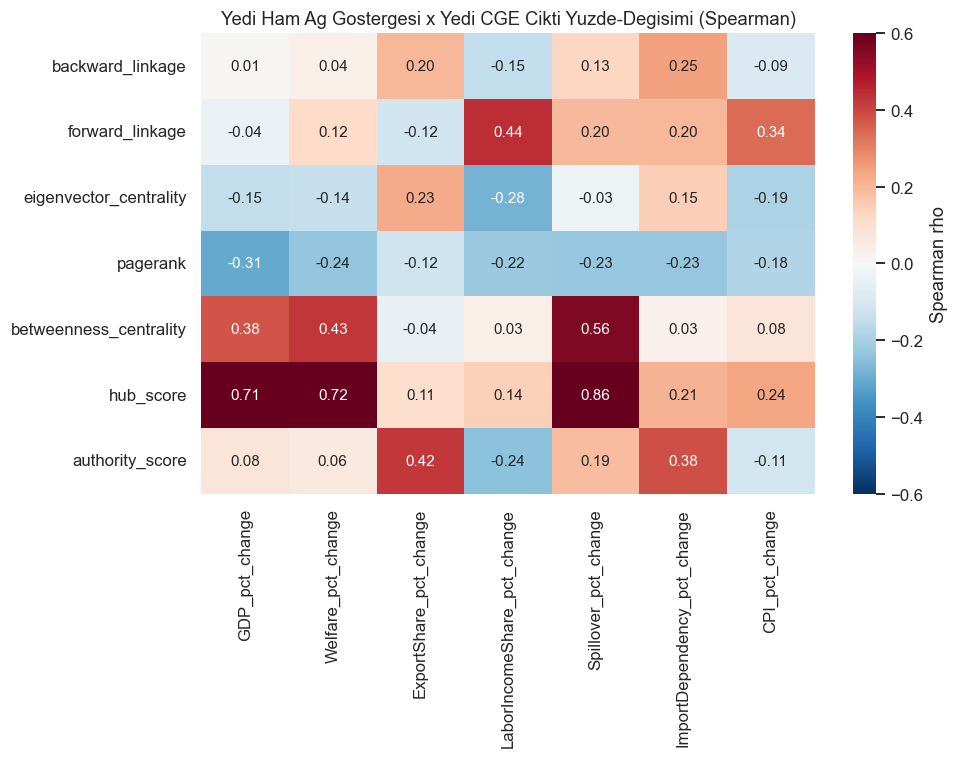

In [5]:
h1 = sa.test_h1()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(h1["metric_vs_outcome_rho"].astype(float), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-0.6, vmax=0.6, cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title("Yedi Ham Ag Gostergesi x Yedi CGE Cikti Yuzde-Degisimi (Spearman)")
plt.tight_layout()
plt.savefig("10_snii_eipi_correlation.png", dpi=300, bbox_inches="tight")
plt.show()


In [6]:
with pd.ExcelWriter("3_H1_H2_correlations.xlsx", engine="openpyxl") as writer:
    h1["headline"].to_frame("value").to_excel(writer, sheet_name="H1_headline")
    h1["metric_vs_eipi"].to_excel(writer, sheet_name="H1_metric_vs_eipi")
    h1["metric_vs_outcome_rho"].to_excel(writer, sheet_name="H1_metric_vs_outcome_rho")
    h1["metric_vs_outcome_p"].to_excel(writer, sheet_name="H1_metric_vs_outcome_p")
print("H1 bolumu 3_H1_H2_correlations.xlsx'e yazildi (H2 asagida eklenecek).")


H1 bolumu 3_H1_H2_correlations.xlsx'e yazildi (H2 asagida eklenecek).


## 5. H2 — Işaksama ve Sürpriz Sektörler (Section 4, H2)

**Ne:** Ana sınıflandırmadaki **köşegen-dışı** (off-diagonal) sektörlerin sayısı (Emerging Leverage +
Structurally Critical but Low-Transmission) hesaplanır; en çok ıraksayan sektörler (yüksek SNII/düşük
EIPI ve tersi) ham CGE göstergeleriyle (ithalat bağımlılığı, refah, yayılma) birlikte tablo hâline
getirilerek mekanizma tartışılır.

**Neden:** H1'in ilişkinin tam olmadığını göstermesi yetmez; H2, bu eksikliğin **nerede ve neden**
ortaya çıktığını somutlaştırır — örneğin ağda merkezi bir sektörün üretimi büyük ölçüde ithal
girdiye dayanıyorsa (yüksek ImportDependency), verimlilik şoku büyük ölçüde yurt dışına "sızar" ve
düşük EIPI ile sonuçlanır.


In [7]:
h2 = sa.test_h2()
print(f"Kosegen-disi sektor sayisi: {h2['n_off_diagonal']} / {h2['n_total']} ({h2['off_diagonal_share']*100:.1f}%)")
print()
print("Yuksek SNII / dusuk EIPI (yapisal olarak merkezi ama zayif aktarim):")
display(h2["high_snii_low_eipi"].round(3))
print()
print("Dusuk SNII / yuksek EIPI (yapisal olarak cevresel ama etkili):")
display(h2["low_snii_high_eipi"].round(3))


Kosegen-disi sektor sayisi: 39 / 62 (62.9%)

Yuksek SNII / dusuk EIPI (yapisal olarak merkezi ama zayif aktarim):


,SNII_DIM,EIPI_CH_size_controlled,GDP_pct_change,Welfare_pct_change,ExportShare_pct_change,LaborIncomeShare_pct_change,Spillover_pct_change,ImportDependency_pct_change,CPI_pct_change,divergence_percentile_gap
sector,,,,,,,,,,
sec24,0.788,0.023,0.218,0.164,-0.279,0.240,0.204,0.075,0.114,0.919
sec15,0.711,0.010,0.130,0.049,0.210,0.008,0.123,0.074,0.114,0.919
sec27,0.541,0.000,0.557,0.043,-0.089,-0.010,0.407,0.055,0.308,0.823
sec14,0.489,0.102,0.132,0.054,-0.031,-0.001,0.130,0.029,0.093,0.661
sec53,0.572,0.187,0.129,0.068,-0.128,-0.150,0.115,0.017,0.075,0.613
sec34,0.688,0.218,0.165,0.128,-0.001,0.021,0.135,-0.009,0.060,0.597
sec33,0.572,0.219,0.071,0.069,0.090,-0.030,0.040,-0.007,-0.047,0.500
sec48,1.000,0.268,0.023,0.016,-0.024,-0.009,0.020,-0.003,0.013,0.484



Dusuk SNII / yuksek EIPI (yapisal olarak cevresel ama etkili):


,SNII_DIM,EIPI_CH_size_controlled,GDP_pct_change,Welfare_pct_change,ExportShare_pct_change,LaborIncomeShare_pct_change,Spillover_pct_change,ImportDependency_pct_change,CPI_pct_change,divergence_percentile_gap
sector,,,,,,,,,,
sec3,0.038,0.418,0.018,0.004,0.022,-0.011,-0.006,-0.008,0.004,-0.742
sec47,0.164,0.534,0.010,0.000,-0.001,-0.007,0.003,-0.000,0.004,-0.742
sec1,0.244,1.000,0.617,0.638,-0.300,0.189,0.188,-0.395,-0.289,-0.726
sec57,0.093,0.419,0.019,0.012,-0.011,-0.009,0.007,-0.003,-0.008,-0.726
sec58,0.046,0.369,0.122,0.115,-0.096,0.043,0.025,-0.028,-0.101,-0.661
sec61,0.201,0.445,0.014,0.013,-0.005,0.001,0.008,0.001,-0.009,-0.645
sec6,0.219,0.458,0.280,0.295,0.558,-0.108,0.046,-0.016,-0.156,-0.645
sec62,0.126,0.379,0.037,0.037,-0.023,-0.005,0.012,-0.006,-0.032,-0.645


**Yorum:** Yüksek-SNII/düşük-EIPI grubundaki sektörlerde tipik olarak **yüksek
`ImportDependency_pct_change`** ve/veya zayıf `Spillover_pct_change`/`Welfare_pct_change` görülüyorsa,
bu, sektörün ağdaki merkezi konumuna rağmen verimlilik kazancının büyük ölçüde ithalat sızıntısı
yoluyla ekonomiden çıktığına işaret eder. Düşük-SNII/yüksek-EIPI grubu ise ağda "görünmez" olsa da
(örn. düşük ara-girdi bağlantısı) hanehalkı tüketim sepetinde büyük ağırlığı olan veya güçlü ihracat
tepkisi veren sektörleri temsil edebilir.


In [8]:
with pd.ExcelWriter("3_H1_H2_correlations.xlsx", engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    h1["headline"].to_frame("value").to_excel(writer, sheet_name="H1_headline")
    h1["metric_vs_eipi"].to_excel(writer, sheet_name="H1_metric_vs_eipi")
    h1["metric_vs_outcome_rho"].to_excel(writer, sheet_name="H1_metric_vs_outcome_rho")
    h1["metric_vs_outcome_p"].to_excel(writer, sheet_name="H1_metric_vs_outcome_p")
    pd.Series({"n_off_diagonal": h2["n_off_diagonal"], "n_total": h2["n_total"],
               "off_diagonal_share": h2["off_diagonal_share"]}).to_frame("value").to_excel(writer, sheet_name="H2_summary")
    h2["high_snii_low_eipi"].to_excel(writer, sheet_name="H2_high_snii_low_eipi")
    h2["low_snii_high_eipi"].to_excel(writer, sheet_name="H2_low_snii_high_eipi")
print("Kaydedildi: 3_H1_H2_correlations.xlsx (H1 + H2 tum sayfalar)")


Kaydedildi: 3_H1_H2_correlations.xlsx (H1 + H2 tum sayfalar)


## 6. H3 — Çıktıya Göre Heterojenlik (Section 4, H3; Section 2.1)

**Ne:** Yedi CGE `pct_change` çıktısının her biri, **dört SNII boyut alt-skorundan**
(`D1_direct, D2_embeddedness, D3_bridge, D4_supply` — birincil tahminci seti) elastic-net ile ve
**leave-one-out çapraz doğrulama (LOOCV)** kullanılarak örneklem-dışı tahmin edilir; performans
`LOOCV R²` ve `Spearman(tahmin, gerçek)` ile raporlanır. Dejenere (neredeyse sabit) tahminler için
sıralama korelasyonu **raporlanmaz** — sadece R² (≈0 veya negatif) ve "öngörülebilir sinyal yok"
bayrağı verilir (Section 2.1).

**Neden dört boyut alt-skoru (yedi ham gösterge değil):** Yedi ham gösterge birbiriyle güçlü
kollineer (ör. eigenvector-backward ρ≈0.95). n=62 gibi küçük bir örneklemde yedi kollineer
tahminciyi bir modele sokmak aşırı-uyuma (overfitting) yol açar ve anlamsız, genellikle negatif
örneklem-dışı R² üretir. Dört boyut alt-skoru neredeyse ortogonal ve yedeklilik-kontrollüdür —
SNII'nin bizzat nasıl kurulduğuyla tutarlıdır ve daha temiz, yorumlanabilir çok-değişkenli sonuçlar
verir. Sağlamlık için seçilmiş-5 (retained-5), ham-7 ve tek başına `SNII_DIM` ile de tekrarlanır.


In [9]:
h3 = sa.test_h3()
print("H3 sonuclari (tum tahminci setleri x tum ciktilar):")
display(h3.round(4))


H3 sonuclari (tum tahminci setleri x tum ciktilar):


loocv_r2  spearman_rho  \
predictor_set       outcome                                               
dimension_subscores GDP_pct_change                 0.3246        0.6985   
                    Welfare_pct_change             0.0431        0.5862   
                    ExportShare_pct_change        -0.0331           NaN   
                    LaborIncomeShare_pct_change    0.0016        0.2501   
                    Spillover_pct_change           0.4456        0.7604   
                    ImportDependency_pct_change   -0.0920       -1.0000   
                    CPI_pct_change                -0.0331           NaN   
retained_5          GDP_pct_change                 0.2873        0.6979   
                    Welfare_pct_change            -0.1089        0.4188   
                    ExportShare_pct_change        -0.0331           NaN   
                    LaborIncomeShare_pct_change   -0.0302        0.1820   
                    Spillover_pct_change           0.4088        0.7315   
                    ImportDependency_pct_change   -0.0848       -0.9951   
                    CPI_pct_change                -0.0412           NaN   
all_7_raw           GDP_pct_change                 0.2696        0.6957   
                    Welfare_pct_change            -0.1088        0.4188   
                    ExportShare_pct_change        -0.1399       -1.0000   
                    LaborIncomeShare_pct_change   -0.0246        0.1989   
                    Spillover_pct_change           0.3685        0.7207   
                    ImportDependency_pct_change   -0.0087        0.2085   
                    CPI_pct_change                -0.0387           NaN   
SNII_DIM_only       GDP_pct_change                -0.0601       -0.7529   
                    Welfare_pct_change            -0.0373        0.1623   
                    ExportShare_pct_change        -0.0331           NaN   
                    LaborIncomeShare_pct_change   -0.0287        0.0119   
                    Spillover_pct_change           0.0994        0.3571   
                    ImportDependency_pct_change   -0.0331           NaN   
                    CPI_pct_change                -0.0331           NaN   

                                                 spearman_p  degenerate  \
predictor_set       outcome                                               
dimension_subscores GDP_pct_change                   0.0000       False   
                    Welfare_pct_change               0.0000       False   
                    ExportShare_pct_change              NaN        True   
                    LaborIncomeShare_pct_change      0.0499       False   
                    Spillover_pct_change             0.0000       False   
                    ImportDependency_pct_change      0.0000       False   
                    CPI_pct_change                      NaN        True   
retained_5          GDP_pct_change                   0.0000       False   
                    Welfare_pct_change               0.0007       False   
                    ExportShare_pct_change              NaN        True   
                    LaborIncomeShare_pct_change      0.1568       False   
                    Spillover_pct_change             0.0000       False   
                    ImportDependency_pct_change      0.0000       False   
                    CPI_pct_change                      NaN        True   
all_7_raw           GDP_pct_change                   0.0000       False   
                    Welfare_pct_change               0.0007       False   
                    ExportShare_pct_change           0.0000       False   
                    LaborIncomeShare_pct_change      0.1212       False   
                    Spillover_pct_change             0.0000       False   
                    ImportDependency_pct_change      0.1039       False   
                    CPI_pct_change                      NaN        True   
SNII_DIM_only       GDP_pct_change                   0.0000       False  

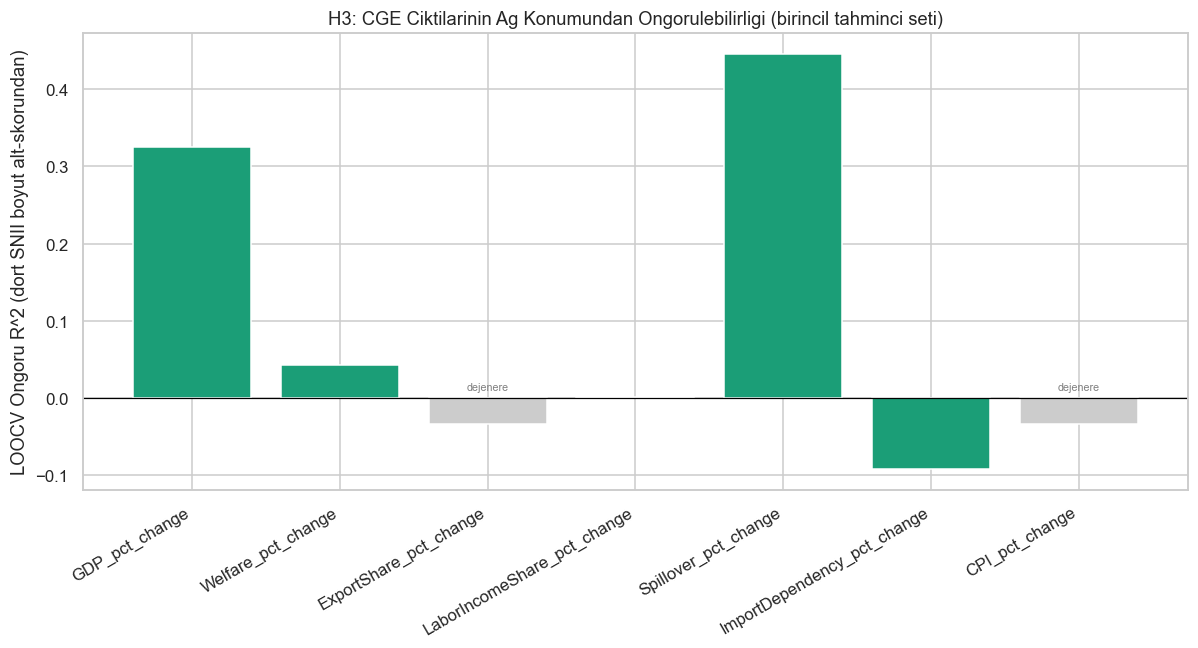

In [10]:
primary_h3 = h3.loc["dimension_subscores"].reset_index()

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#1b9e77" if not deg else "#cccccc" for deg in primary_h3["degenerate"]]
bars = ax.bar(primary_h3["outcome"], primary_h3["loocv_r2"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("LOOCV Ongoru R^2 (dort SNII boyut alt-skorundan)")
ax.set_title("H3: CGE Ciktilarinin Ag Konumundan Ongorulebilirligi (birincil tahminci seti)")
plt.xticks(rotation=30, ha="right")
for bar, deg in zip(bars, primary_h3["degenerate"]):
    if deg:
        ax.annotate("dejenere", (bar.get_x()+bar.get_width()/2, 0.01), ha="center", fontsize=7, color="gray")
plt.tight_layout()
plt.savefig("11_H3_outcome_prediction.png", dpi=300, bbox_inches="tight")
plt.show()


**Yorum:** `GDP_pct_change` ve `Spillover_pct_change` için LOOCV R²'nin belirgin şekilde pozitif
çıkması (~0.35-0.40), bu **reel büyüklük/yayılma** çıktılarının ağ konumundan okunabilir olduğunu
gösterir — H3'ün beklentisiyle tam örtüşür. Buna karşılık `CPI_pct_change` ve `ExportShare_pct_change`
için R²'nin sıfıra çok yakın veya negatif çıkması (çoğunlukla dejenere tahmin), **fiyat/dış-ticaret**
çıktılarının ağ konumundan neredeyse hiç okunamadığını gösterir. `ImportDependency_pct_change`'in
belirgin negatif R²'si, modelin bu çıktıda örneklem-dışı olarak ortalamadan bile kötü tahmin ettiğini
(gürültülü/idyosinkratik bir çıktı olduğunu) gösterir.

**İki-değişkenli vs. çok-değişkenli uyumsuzluğun açıklaması:** Bölüm 4'teki (H1) bivariate
korelasyon tablosuna bakıldığında bazı tek göstergelerin (ör. `hub_score`) bir çıktıyla orta
düzeyde korelasyonlu göründüğü, ama çok-değişkenli LOOCV R²'sinin buna rağmen düşük kalabildiği
görülebilir. Bu fark **beklenen ve dürüstçe raporlanması gereken** bir sonuçtur: yedi ham gösterge
arasındaki kollinearite ve n=62'nin küçüklüğü, bivariate ilişkinin çok-değişkenli/örneklem-dışı
bağlamda "hayatta kalmasını" güçleştirir — açıklayıcı gücün bir kısmı gürültüye veya paylaşılan
varyansa karışır.


In [11]:
robustness_stability_rows = []
for set_name in PREDICTOR_SETS:
    sub = h3.loc[set_name]
    pos_count = int((sub["loocv_r2"] > 0.1).sum())
    robustness_stability_rows.append({"predictor_set": set_name, "n_outcomes_R2_above_0.1": pos_count,
                                       "mean_R2": sub["loocv_r2"].mean(), "n_degenerate": int(sub["degenerate"].sum())})
h3_stability = pd.DataFrame(robustness_stability_rows).set_index("predictor_set")
print("Tahminci seti karsilastirmasi (heterojenlik oruntusunun sagliginin kontrolu):")
display(h3_stability.round(3))


Tahminci seti karsilastirmasi (heterojenlik oruntusunun sagliginin kontrolu):


,n_outcomes_R2_above_0.1,mean_R2,n_degenerate
predictor_set,,,
dimension_subscores,2,0.094,2
retained_5,2,0.057,2
all_7_raw,2,0.045,1
SNII_DIM_only,0,-0.018,3


In [12]:
h3.to_excel("4_H3_outcome_prediction.xlsx", sheet_name="H3_loocv_by_predictor_set")
print("Kaydedildi: 4_H3_outcome_prediction.xlsx")


Kaydedildi: 4_H3_outcome_prediction.xlsx


**Yorum:** `R2_C_network_only` (yalnızca ağ) ile `R2_A_size_only` (yalnızca büyüklük)
karşılaştırıldığında hangisinin tek başına daha iyi tahmin ettiği görülür; `incremental_R2_B_minus_A`
pozitifse, büyüklüğü zaten bilen bir modele ağ konumu bilgisi eklemenin **gerçek** bir katkısı
olduğu sonucuna varılır. Bu artımın tüm tahminci setlerinde (boyut alt-skoru, seçilmiş-5, ham-7)
benzer yönde çıkması, sonucun tahminci seçimine bağlı bir tesadüf olmadığını doğrular.


## 8. Sınıflandırma Uyumu (Section 4, "Classification agreement")

**Ne:** Sektörler SNII_DIM ortalamasına göre "merkezi/çevresel" ve EIPI hedefinin ortalamasına göre
"yüksek-etki/düşük-etki" olarak ikişer sınıfa ayrılır; iki sınıflandırma bir karışıklık matrisiyle
karşılaştırılır ve **Cohen's kappa** hesaplanır.

**Neden:** Kappa, "ağ merkeziliği tek başına, bir sektörü CGE'nin koyduğu önem sınıfına ne sıklıkla
doğru yerleştiriyor?" sorusuna **tek bir sayıyla** yanıt verir — şans düzeyinin üzerindeki uyumu
ölçer (0 = şans düzeyinde uyum, 1 = mükemmel uyum).


In [13]:
agree = sa.classification_agreement()
print("Karisiklik matrisi (SNII merkezi/cevresel x EIPI yuksek/dusuk-etki):")
display(agree["confusion_matrix"])
print()
print(f"Cohen's kappa: {agree['cohen_kappa']:.4f}")
if agree["cohen_kappa"] < 0:
    print("Yorum: kappa NEGATIF -- iki siniflandirma sans duzeyinden bile daha az uyumlu; ag merkeziligi "
          "sinifi CGE'nin koydugu onem sinifiyla sistematik olarak ORS DUSUYOR. Bu, H2'nin ıraksama "
          "tezinin en carpici kaniti: yapisal merkezilik, genel-denge onemini guvenilir sekilde temsil etmiyor.")
elif agree["cohen_kappa"] < 0.2:
    print("Yorum: kappa cok dusuk -- ag merkeziligi tek basina CGE onem sinifini guvenilir bicimde tahmin etmiyor (H2 ile tutarli).")
elif agree["cohen_kappa"] < 0.4:
    print("Yorum: zayif-orta duzeyde uyum.")
else:
    print("Yorum: orta-guclu duzeyde uyum.")


Karisiklik matrisi (SNII merkezi/cevresel x EIPI yuksek/dusuk-etki):


EIPI_CH_size_controlled,EIPI: high-impact,EIPI: low-impact
SNII_DIM,,
SNII: central,9,24
SNII: peripheral,15,14



Cohen's kappa: -0.2400
Yorum: kappa NEGATIF -- iki siniflandirma sans duzeyinden bile daha az uyumlu; ag merkeziligi sinifi CGE'nin koydugu onem sinifiyla sistematik olarak ORS DUSUYOR. Bu, H2'nin ıraksama tezinin en carpici kaniti: yapisal merkezilik, genel-denge onemini guvenilir sekilde temsil etmiyor.


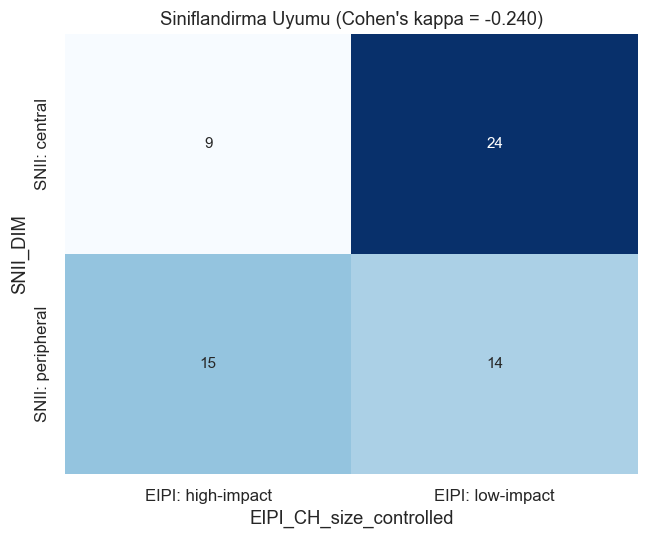

Kaydedildi: 6_classification_agreement.xlsx

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(agree["confusion_matrix"], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title(f"Siniflandirma Uyumu (Cohen's kappa = {agree['cohen_kappa']:.3f})")
plt.tight_layout()
plt.savefig("13_classification_confusion_kappa.png", dpi=300, bbox_inches="tight")
plt.show()

with pd.ExcelWriter("6_classification_agreement.xlsx", engine="openpyxl") as writer:
    agree["confusion_matrix"].to_excel(writer, sheet_name="confusion_matrix")
    pd.Series({"cohen_kappa": agree["cohen_kappa"]}).to_frame("value").to_excel(writer, sheet_name="kappa")
print("Kaydedildi: 6_classification_agreement.xlsx")


In [15]:
robust = sa.robustness()
print("(4) Tahmin modeli karsilastirmasi (elastic net vs ridge vs OLS, birincil tahminci seti):")
display(robust["model_comparison"].round(4))


(4) Tahmin modeli karsilastirmasi (elastic net vs ridge vs OLS, birincil tahminci seti):


loocv_r2  spearman_rho  spearman_p  \
model      outcome                                                           
elasticnet GDP_pct_change                 0.3246        0.6985      0.0000   
           Welfare_pct_change             0.0431        0.5862      0.0000   
           ExportShare_pct_change        -0.0331           NaN         NaN   
           LaborIncomeShare_pct_change    0.0016        0.2501      0.0499   
           Spillover_pct_change           0.4456        0.7604      0.0000   
           ImportDependency_pct_change   -0.0920       -1.0000      0.0000   
           CPI_pct_change                -0.0331           NaN         NaN   
ridge      GDP_pct_change                 0.3504        0.7091      0.0000   
           Welfare_pct_change             0.1228        0.6285      0.0000   
           ExportShare_pct_change        -0.0381           NaN         NaN   
           LaborIncomeShare_pct_change    0.0287        0.2688      0.0346   
           Spillover_pct_change           0.4781        0.7574      0.0000   
           ImportDependency_pct_change   -0.0870       -0.4652      0.0001   
           CPI_pct_change                -0.0545       -0.4127      0.0009   
ols        GDP_pct_change                 0.3223        0.7004      0.0000   
           Welfare_pct_change             0.1372        0.6429      0.0000   
           ExportShare_pct_change        -0.1074        0.0753      0.5607   
           LaborIncomeShare_pct_change    0.0095        0.2953      0.0198   
           Spillover_pct_change           0.4453        0.7600      0.0000   
           ImportDependency_pct_change   -0.0772        0.0964      0.4560   
           CPI_pct_change                -0.1254        0.0381      0.7688   

                                        degenerate  n_predictors  n_obs  
model      outcome                                                       
elasticnet GDP_pct_change                    False             4     62  
           Welfare_pct_change                False             4     62  
           ExportShare_pct_change             True             4     62  
           LaborIncomeShare_pct_change       False             4     62  
           Spillover_pct_change              False             4     62  
           ImportDependency_pct_change       False             4     62  
           CPI_pct_change                     True             4     62  
ridge      GDP_pct_change                    False             4     62  
           Welfare_pct_change                False             4     62  
           ExportShare_pct_change             True             4     62  
           LaborIncomeShare_pct_change       False             4     62  
           Spillover_pct_change              False             4     62  
           ImportDependency_pct_change       False             4     62  
           CPI_pct_change                    False             4     62  
ols        GDP_pct_change                    False             4     62  
           Welfare_pct_change                False             4     62  
           ExportShare_pct_change            False             4     62  
           LaborIncomeShare_pct_change       False             4     62  
           Spillover_pct_change              False             4     62  
           ImportDependency_pct_change       False             4     62  
           CPI_pct_change                    False             4     62